In [48]:
import torch
import tiktoken
enc=tiktoken.get_encoding('gpt2')

In [49]:
from train_gpt2 import GPT2Config,GPT2
checkpoint=torch.load("gpt2_step_11500.pt",map_location="cpu")
for key in list(checkpoint.keys()):
    if key.startswith('_orig_mod.'):
        checkpoint[key[len('_orig_mod.'):]]=checkpoint.pop(key)

model=GPT2(GPT2Config())
model.load_state_dict(checkpoint,strict=False)

_IncompatibleKeys(missing_keys=['transformer.h.0.attn.bias', 'transformer.h.1.attn.bias', 'transformer.h.2.attn.bias', 'transformer.h.3.attn.bias', 'transformer.h.4.attn.bias', 'transformer.h.5.attn.bias', 'transformer.h.6.attn.bias', 'transformer.h.7.attn.bias', 'transformer.h.8.attn.bias', 'transformer.h.9.attn.bias', 'transformer.h.10.attn.bias', 'transformer.h.11.attn.bias'], unexpected_keys=[])

In [50]:
text_1="The mat cat on sat the"
tokens=enc.encode(text_1)
print(tokens)
input_tokens=torch.tensor(tokens).unsqueeze(0)

[464, 2603, 3797, 319, 3332, 262]


In [51]:
output,_=model(input_tokens)
print(output.shape)

torch.Size([1, 6, 50304])


In [52]:
att=model.transformer.h[0].attn.last_att
print(att.shape)

torch.Size([1, 12, 6, 6])


In [53]:
token_strings=[enc.decode([t]) for t in tokens]
print(token_strings)

['The', ' mat', ' cat', ' on', ' sat', ' the']


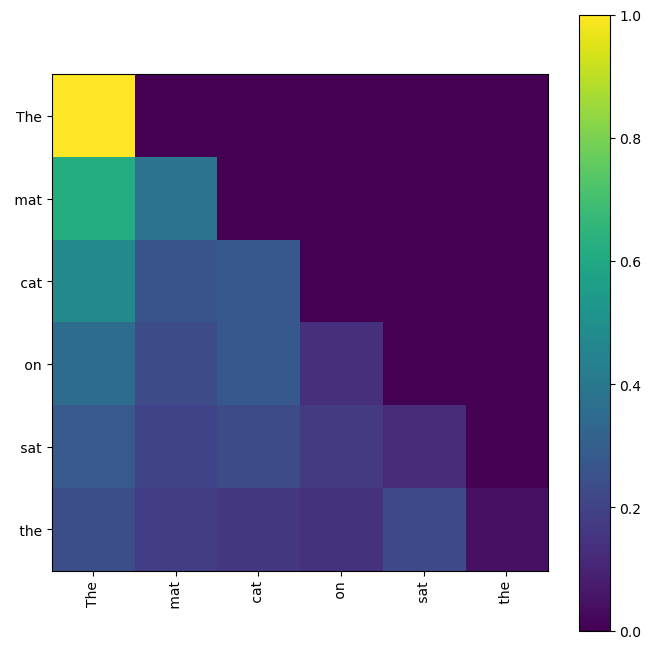

In [54]:
import matplotlib.pyplot as plt
head0=att[0,0]

plt.figure(figsize=(8,8))
plt.imshow(head0)
plt.xticks(range(len(token_strings)),token_strings,rotation=90)
plt.yticks(range(len(token_strings)),token_strings)
plt.colorbar()
plt.show()